***Ploynomial Regression Implementation***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
dataEnergy = pd.DataFrame({
    'Temperature': [1,2,3,4,5,6,7,8],
    'EnergyConsumption': [2,5,9,15,14,10,5,1]
})
dataEnergy

,Temperature,EnergyConsumption
0,1,2
1,2,5
2,3,9
3,4,15
4,5,14
5,6,10
6,7,5
7,8,1


<Axes: xlabel='Temperature', ylabel='EnergyConsumption'>

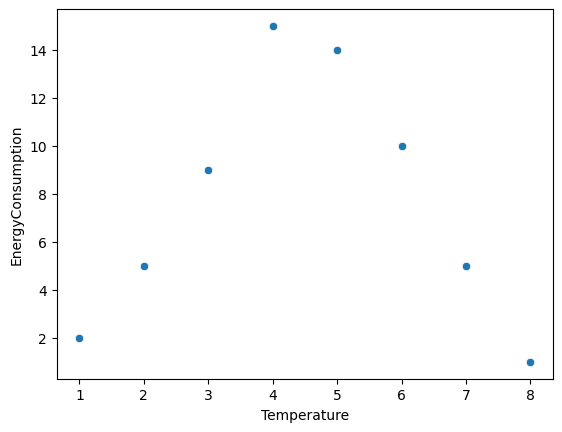

In [3]:
sns.scatterplot(data = dataEnergy, x = 'Temperature', y = 'EnergyConsumption')

In [4]:
x = dataEnergy[['Temperature']]
y = dataEnergy[['EnergyConsumption']]
x_poly = PolynomialFeatures(degree = 2).fit_transform(x)
print(x_poly)


[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]
 [ 1.  7. 49.]
 [ 1.  8. 64.]]


In [5]:
model = LinearRegression().fit(x_poly, y)
print(f"Intercept(c): {model.intercept_}")
print(f"Coefficients (mi): {model.coef_}")

Intercept(c): [-7.375]
Coefficients (mi): [[ 0.          9.10119048 -1.01785714]]


In [6]:
energy_consumption_predicted = model.predict(x_poly)
energy_consumption_predicted

array([[ 0.70833333],
       [ 6.75595238],
       [10.76785714],
       [12.74404762],
       [12.68452381],
       [10.58928571],
       [ 6.45833333],
       [ 0.29166667]])

In [7]:
# for value 2
# energy_consumption_predicted2 = model.predict([[1,2,4]])
# better way
energy_consumption_predicted2 = model.predict(PolynomialFeatures(degree = 2).fit_transform([[2]]))
energy_consumption_predicted2


array([[6.75595238]])

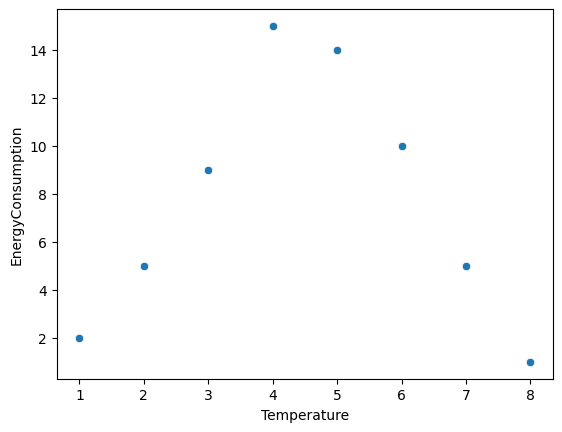

In [8]:
sns.scatterplot(data = dataEnergy, x = 'Temperature', y = 'EnergyConsumption')
plt.show()

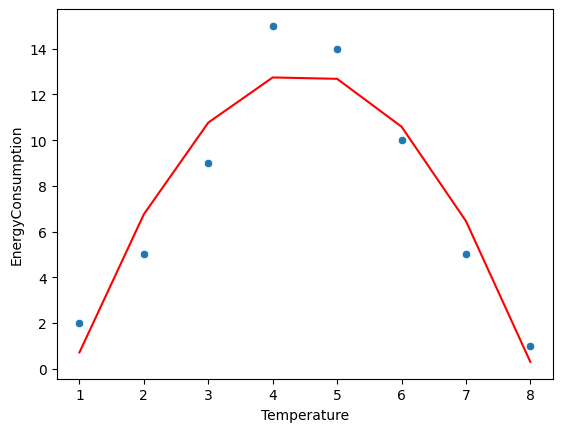

In [9]:
sns.scatterplot(data = dataEnergy, x = 'Temperature', y = 'EnergyConsumption')
sns.lineplot(x = dataEnergy['Temperature'], y = energy_consumption_predicted.flatten(), color = 'red')
plt.show()

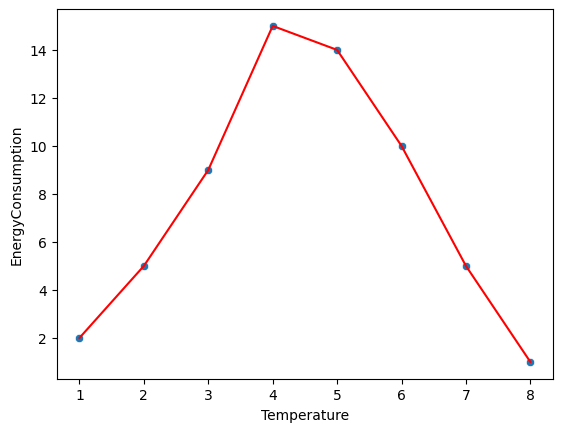

In [10]:
sns.scatterplot(data = dataEnergy, x = 'Temperature', y = 'EnergyConsumption')
sns.lineplot(x = dataEnergy['Temperature'], y = dataEnergy['EnergyConsumption'], color = 'red')
plt.show()

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(dataEnergy['EnergyConsumption'], energy_consumption_predicted)
print(f" r2 score is: {r2:.6f}")
print(f" r2 score in precentage is: {r2*100:.2f}%")

 r2 score is: 0.907895
 r2 score in precentage is: 90.79%


In [12]:
mean_abs_er = mean_absolute_error(dataEnergy['EnergyConsumption'], energy_consumption_predicted)
print(f" Mean Abs Error is: {mean_abs_er:.6f}")

 Mean Abs Error is: 1.392857
